In [1]:
import sys
import os
import subprocess
from pathlib import Path

if 'google.colab' in sys.modules:
    os.environ["OMP_NUM_THREADS"] = "2"
    !pip install -U ipython
    !git clone https://github.com/AdrianPanasiewicz/QML_for_radar_classification.git

    repo_url = "https://github.com/AdrianPanasiewicz/QML_for_radar_classification.git"
    repo_path = "/content/QML_for_radar_classification"
    colab_run_dir = os.path.join(repo_path, 'colab_run')

    def run(cmd, cwd=None):
        return subprocess.check_output(cmd, cwd=cwd, text=True).strip()

    if not os.path.isdir(os.path.join(repo_path, ".git")):
        run(["git", "clone", repo_url, repo_path])
    else:
        run(["git", "fetch", "origin"], cwd=repo_path)
        local_head = run(["git", "rev-parse", "HEAD"], cwd=repo_path)
        remote_head = run(["git", "rev-parse", "origin/HEAD"], cwd=repo_path)
        if local_head != remote_head:
            run(["git", "reset", "--hard", "origin/HEAD"], cwd=repo_path)

    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

    os.makedirs(colab_run_dir, exist_ok=True)
    os.chdir(colab_run_dir)

    !pip install -q pennylane
    !pip install "ray[tune]"

    from google.colab import drive
    drive.mount('/content/drive')
    os.environ["RAY_CHDIR_TO_TRIAL_DIR"] = "0"

else:
    os.environ["OMP_NUM_THREADS"] = "12"


%load_ext autoreload
%autoreload 2

%aimport -torch
%aimport -numpy
%aimport -qiskit
%aimport -pennylane
%aimport -ray
%aimport -sklearn

# These import from Data folder are necessary for pickle load to work
from Data.Primitives.environment_classes import Drone, Radar, Context
from Data.Primitives.noise_models import AdditiveWhiteGaussianNoise
from Data.Primitives.presets import *
from Data.Generators.synthetic_dataset_generator import DatasetMetadata, DataRequest

from MachineLearning.Processing.file_loader import SyntheticDataFileLoader
from MachineLearning.Processing.frequency_domain_parser import FrequencyDomainDataParser
from MachineLearning.Processing.time_domain_parser import TimeDomainDataParser
from MachineLearning.Torch_datasets.synthetic_time_dataset import SyntheticTimeDomainRadarDataset
from MachineLearning.Torch_datasets.synthetic_frequency_dataset import SyntheticFrequencyDomainRadarDataset
from MachineLearning.Models.experiment_pure.classical_neural_network import ClassicalNeuralNetwork
from MachineLearning.Models.experiment_pure.quantum_neural_network import QuantumNeuralNetwork
from MachineLearning.Processing.data_visualizer import DataVisualizer
from MachineLearning.Trainers.statistical_trainer import StatisticalTrainer
from MachineLearning.Trainers.hyperparameter_trainer import HyperparameterTrainer

from matplotlib import pyplot as plt
import numpy as np

from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import sympy

import torch
from torch import nn
from torch.nn.functional import normalize
from torch.utils.data import DataLoader
from torch.optim import SGD

import pennylane as qml
import optuna

import ray
from ray import tune
from ray.tune import Checkpoint, CheckpointConfig, RunConfig
from ray.tune.schedulers import ASHAScheduler

# Checking preprocessing functionalities

In [ ]:
PROJECT_ROOT = Path().cwd().parent
type = "time_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = TimeDomainDataParser()
signal, label, misc_data = td_data_parser.extract_training_data_and_label(obj)
td_data_parser.plot_drone_spectrogram(signal, misc_data, nperseg=32, noverlap=16)

In [ ]:
parsed_signal, label, misc_data = td_data_parser.parse_data_object(obj)
parsed_signal, label, misc_data

In [ ]:
PROJECT_ROOT = Path().cwd().parent
type = "frequency_domain"
load_path = PROJECT_ROOT / "Data" / "Datasets" / type / "training_dataset.pkl"

md = DatasetMetadata.create_from_path(load_path)
synt_dataset = SyntheticDataFileLoader(dataset_metadata=md)

obj = synt_dataset.peek_sample(index=6000)

td_data_parser = FrequencyDomainDataParser()
signal, label, misc_data = td_data_parser.parse_data_object(obj, bin_size=1, return_mag=False)
print(signal.shape)

# Classical Neural Network

### Hyperparameter learner

In [2]:
try:
    from google.colab import output
    if 'google.colab' in sys.modules:
        IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = Path().cwd().parent
ray.shutdown()

ctx = ray.init(
    _metrics_export_port=8080,
    runtime_env={
        "working_dir": str(PROJECT_ROOT),
        "excludes": [
            "Data/Datasets"
        ]
    }
)

if IN_COLAB:
    print("Loading Ray Dashboard:")
    output.serve_kernel_port_as_iframe(8265, height=600)

    print("Loading Ray Metrics Export:")
    output.serve_kernel_port_as_iframe(8080, height=400)
else:
    print(f"Running locally. Dashboard available at: {ctx.dashboard_url}")
    print("Metrics available at: http://127.0.0.1:8080")

2026-04-22 20:37:25,346	INFO worker.py:2014 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2026-04-22 20:37:26,122	INFO packaging.py:588 -- Creating a file package for local module 'E:\Zycie\Nauka\Studia\Inf\Praca dyplomowa\Thesis_project\QML_for_radar_classification'.
2026-04-22 20:37:26,190	WARNING packaging.py:430 -- File E:\Zycie\Nauka\Studia\Inf\Praca dyplomowa\Thesis_project\QML_for_radar_classification\.git\objects\31\9db0d1654352e4db09aece7c618a7d83cc7308 is very large (14.43MiB). Consider adding this file to the 'excludes' list to skip uploading it: `ray.init(..., runtime_env={'excludes': ['E:\Zycie\Nauka\Studia\Inf\Praca dyplomowa\Thesis_project\QML_for_radar_classification\.git\objects\31\9db0d1654352e4db09aece7c618a7d83cc7308']})`
2026-04-22 20:37:26,556	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_50d1419dea7c6e32.zip' (33.14MiB) to Ray cluster...
2026-04-22 20:37:26,651	INFO packaging.py:393 -- Successfully pushed file packa

Running locally. Dashboard available at: 127.0.0.1:8265
Metrics available at: http://127.0.0.1:8080


C:\Users\adria\miniconda3\envs\Qiskit_workshop\Lib\site-packages\ray\_private\worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
(train_model pid=20696) Checkpoint successfully created at: Checkpoint(filesystem=local, path=E:/ray_results/radar_hparam_search/t_53d04_00001/checkpoint_000000)
(train_model pid=21976) Checkpoint successfully created at: Checkpoint(filesystem=local, path=E:/ray_results/radar_hparam_search/t_53d04_00002/checkpoint_000001) [repeated 5x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(train_model pid=21976) Checkpoint successfully created at: Checkpoint(f

In [ ]:
config_params = 32
divs_array = sympy.divisors(config_params)

pair_map = {div : config_params // div for div in divs_array}


model_config = {
    "layers": tune.grid_search(list(pair_map.keys())),
    "neurons_per_layer": tune.sample_from(lambda config: pair_map[config["model_config"]["layers"]]),
}
training_config = {
	"batch_size": tune.choice([2, 4, 8, 16, 32]),
	"device": "cuda" if torch.cuda.is_available() else "cpu",
	"epochs": 50,
	"optimizer": {
	    "name" : tune.choice(["SGD", "Adam"]),
        "lr": tune.loguniform(1e-5, 1e-1),
        "momentum": tune.uniform(0, 1),
	}
}

config = {
	"model_config": model_config,
	"training_config": training_config,
}


max_num_epochs = training_config["epochs"]
num_trials =  5
scheduler = ASHAScheduler(
    max_t=max_num_epochs,
    grace_period=10,
    reduction_factor=2,
)

cpus_per_trial = 4
gpus_per_trial = 0

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = HyperparameterTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=testing_path,
    criterion = nn.CrossEntropyLoss()
)


tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(trainer.train_model, model_class=ClassicalNeuralNetwork),
        resources={"cpu": cpus_per_trial, "gpu": gpus_per_trial}
    ),
    tune_config=tune.TuneConfig(
        metric="accuracy",
        mode="max",
        scheduler=scheduler,
        num_samples=num_trials,
        trial_dirname_creator=lambda trial: f"t_{trial.trial_id}"
    ),
    run_config = RunConfig(
    storage_path= "/content/drive/MyDrive/ray_results" if 'google.colab' in sys.modules else "E:/ray_results",
    checkpoint_config=CheckpointConfig(
            num_to_keep=2,
            checkpoint_score_attribute="accuracy",
            checkpoint_score_order="max",
        ),
    name="radar_hparam_search_cnn",
	),
    param_space=config,
)
results = tuner.fit()

# Current best trial: 8f0ab_00008 with loss=0.4411230981349945 and params={'layers': 1, 'neurons_per_layer': 128, 'lr': 9.763374597090547e-05, 'batch_size': 4, 'device': 'cuda', 'epochs': 250}
# Current best trial: 7a17b_00064 with loss=0.43200549483299255 and params={'layers': 2, 'neurons_per_layer': 32, 'lr': 0.000471644, 'batch_size': 2, 'device': 'cpu', 'epochs': 160}
# 32 params batch size 8	layers 1	0.000148743	250	81.1576	0.493999	0.746429

### Statistical learner

In [5]:
def l1_normalize_1d(x):
    return normalize(x, p=1, dim=0)

def l2_normalize_1d(x):
    return normalize(x, dim=0)

In [20]:
PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

model_config = {
    "layers": 1,
    "neurons_per_layer": 256,
}
training_config = {
    "lr": 9.763374597090547e-05,
    "batch_size": 4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "epochs": 2,
    "number_of_trials" : 1
}

config = {
    "model_config": model_config,
    "training_config": training_config,
}

trainer = StatisticalTrainer(training_path, validating_path, testing_path, criterion = nn.CrossEntropyLoss())
data_array_all_runs = trainer.train_model(ClassicalNeuralNetwork, config)

Model runs: 100%|██████████| 1/1 [00:26<00:00, 26.28s/it]


(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Model Accuracy During Training'}, xlabel='Epoch', ylabel='Accuracy [%]'>)

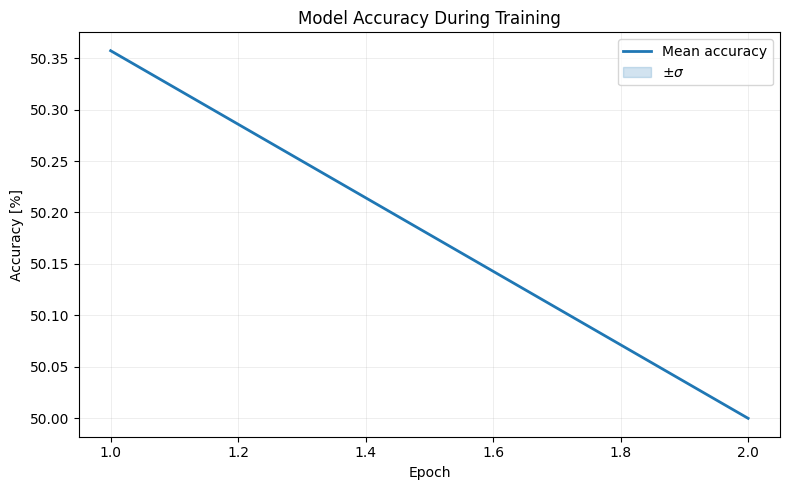

In [21]:
data_array = torch.tensor(
    [data_array_all_runs[i]['accuracy'] for i in range(len(data_array_all_runs))],
    dtype=torch.float32
)

plotter = DataVisualizer()
means, stds = plotter.calculate_statistics(data_array)
plotter.plot_statistics(means, stds)

# Quantum Neural Network

## Hyperparameter learner

### Ray searcher

In [2]:
try:
    from google.colab import output
    if 'google.colab' in sys.modules:
        IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = Path().cwd().parent
ray.shutdown()

ctx = ray.init(
    _metrics_export_port=8080,
    runtime_env={
        "working_dir": str(PROJECT_ROOT),
        "excludes": [
            "Data/Datasets"
        ]
    }
)

if IN_COLAB:
    print("Loading Ray Dashboard:")
    output.serve_kernel_port_as_iframe(8265, height=600)

    print("Loading Ray Metrics Export:")
    output.serve_kernel_port_as_iframe(8080, height=400)
else:
    print(f"Running locally. Dashboard available at: {ctx.dashboard_url}")
    print("Metrics available at: http://127.0.0.1:8080")

2026-04-23 09:01:06,622	INFO worker.py:2014 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
2026-04-23 09:01:07,441	INFO packaging.py:588 -- Creating a file package for local module 'E:\Zycie\Nauka\Studia\Inf\Praca dyplomowa\Thesis_project\QML_for_radar_classification'.
2026-04-23 09:01:07,506	WARNING packaging.py:430 -- File E:\Zycie\Nauka\Studia\Inf\Praca dyplomowa\Thesis_project\QML_for_radar_classification\.git\objects\31\9db0d1654352e4db09aece7c618a7d83cc7308 is very large (14.43MiB). Consider adding this file to the 'excludes' list to skip uploading it: `ray.init(..., runtime_env={'excludes': ['E:\Zycie\Nauka\Studia\Inf\Praca dyplomowa\Thesis_project\QML_for_radar_classification\.git\objects\31\9db0d1654352e4db09aece7c618a7d83cc7308']})`
2026-04-23 09:01:07,915	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_23bc6d81323ba3e9.zip' (33.32MiB) to Ray cluster...
2026-04-23 09:01:08,043	INFO packaging.py:393 -- Successfully pushed file packa

Running locally. Dashboard available at: 127.0.0.1:8265
Metrics available at: http://127.0.0.1:8080


C:\Users\adria\miniconda3\envs\Qiskit_workshop\Lib\site-packages\ray\_private\worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
(train_model pid=27544) Checkpoint successfully created at: Checkpoint(filesystem=local, path=E:/ray_results/radar_hparam_search_qnn/t_384f9_00000/checkpoint_000000)
(train_model pid=27544) Checkpoint successfully created at: Checkpoint(filesystem=local, path=E:/ray_results/radar_hparam_search_qnn/t_384f9_00000/checkpoint_000001)


In [ ]:
model_config = {
    "n_qubits"  : 10,
    "layers"    : tune.choice([1,2,3,4,5]),
    "encoding"  : tune.choice(["angle", "amplitude"]),
    "ansatz"    : tune.choice(["basic", "entangling", "random"]),
    "simulator" : 'default.qubit',
}
training_config = {
	"batch_size": tune.choice([2, 4, 8, 16, 32]),
	"device": "cpu",
	"epochs": 50,
	"optimizer": {
	    "name" : tune.choice(["SGD", "Adam"]),
        "lr": tune.loguniform(1e-5, 1e-1),
        "momentum": tune.uniform(0, 1),
        "weight_decay": tune.loguniform(1e-6, 1e-3),
	}
}

config = {
	"model_config": model_config,
	"training_config": training_config,
}

max_num_epochs = training_config["epochs"]
num_trials =  100
scheduler = ASHAScheduler(
    max_t=max_num_epochs,
    grace_period=10,
    reduction_factor=2,
)

cpus_per_trial = 12
gpus_per_trial = 0

PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = HyperparameterTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=testing_path,
    criterion = nn.BCELoss()
)

tuner = tune.Tuner(
    tune.with_resources(
        tune.with_parameters(trainer.train_model, model_class=QuantumNeuralNetwork),
        resources={"cpu": cpus_per_trial, "gpu": gpus_per_trial}
    ),
    tune_config=tune.TuneConfig(
        metric="accuracy",
        mode="max",
        scheduler=scheduler,
        num_samples=num_trials,
        trial_dirname_creator=lambda trial: f"t_{trial.trial_id}"
    ),
    run_config = RunConfig(
    storage_path= "/content/drive/MyDrive/ray_results" if 'google.colab' in sys.modules else "E:/ray_results",
    checkpoint_config=CheckpointConfig(
            num_to_keep=2,
            checkpoint_score_attribute="accuracy",
            checkpoint_score_order="max",
        ),
    name="radar_hparam_search_qnn",
    verbose=1
	),
    param_space=config,
)
results = tuner.fit()

### Optuna seach

In [ ]:
PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = HyperparameterTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=testing_path,
    criterion=nn.BCELoss()
)

def objective(trial):
    model_config = {
        "n_qubits": 10,
        "layers": trial.suggest_int("layers", 1, 5),
        "encoding": trial.suggest_categorical("encoding", ["angle", "amplitude"]),
        "ansatz": trial.suggest_categorical("ansatz", ["basic", "entangling", "random"]),
        "simulator": "default.qubit",
    }

    training_config = {
    "batch_size": trial.suggest_categorical("batch_size", [2, 4, 8, 16, 32]),
	"device": "cpu",
	"epochs": 20,
	"optimizer": {
	    "name" : trial.suggest_categorical("optimizer_name", ["SGD", "Adam"]),
        "lr": trial.suggest_float("lr", 1e-3, 1e-1, log=True),
        "momentum": trial.suggest_float("momentum", 0.0, 1.0) if trial.params.get("optimizer_name") == "SGD" else 0,
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        },
	}

    config = {
        "model_config" : model_config,
        "training_config" : training_config,
    }

    accuracy = trainer.train_model(trial, config, QuantumNeuralNetwork)
    return accuracy

pruner = optuna.pruners.HyperbandPruner(
        min_resource=5,
        reduction_factor=2
    )

study = optuna.create_study(direction="maximize", pruner=pruner)
print("Starting Optuna Hyperparameter Search...")

study.optimize(objective, n_trials=200)

print("\n" + "="*50)
print("HYPERPARAMETER SEARCH COMPLETED")
print(f"Best trial final validation accuracy: {study.best_value:.4f}")
print(f"Best trial config: {study.best_params}")
print("="*50)

# [I 2026-04-23 19:03:28,113] Trial 7 finished with value: 0.6428571428571429 and parameters: {'layers': 5, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 2, 'optimizer_name': 'Adam', 'lr': 0.0010560909021002144, 'weight_decay': 1.590794237146988e-06}. Best is trial 7 with value: 0.6428571428571429.

[I 2026-04-24 08:25:40,225] A new study created in memory with name: no-name-67dfd136-4fdf-491b-8efb-92a3416db4f8


Starting Optuna Hyperparameter Search...


Epochs:  70%|███████   | 14/20 [06:06<02:40, 26.74s/it]

### Optuna results

In [ ]:
# [I 2026-04-23 16:58:10,230] A new study created in memory with name: no-name-887f9a4c-c8e7-4061-bf86-d092fef3adf8
# Starting Optuna Hyperparameter Search...
# Epochs: 100%|██████████| 20/20 [15:59<00:00, 47.98s/it]
# [I 2026-04-23 17:14:11,856] Trial 0 finished with value: 0.5071428571428571 and parameters: {'layers': 4, 'encoding': 'angle', 'ansatz': 'basic', 'batch_size': 4, 'optimizer_name': 'SGD', 'lr': 0.008857144956485836, 'momentum': 0.5364933018354858, 'weight_decay': 0.00020254586329384477}. Best is trial 0 with value: 0.5071428571428571.
# Epochs: 100%|██████████| 20/20 [12:09<00:00, 36.46s/it]
# [I 2026-04-23 17:26:21,052] Trial 1 finished with value: 0.5 and parameters: {'layers': 1, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 4, 'optimizer_name': 'SGD', 'lr': 0.015043159032410464, 'momentum': 0.20439746504358958, 'weight_decay': 0.00012445243078634984}. Best is trial 0 with value: 0.5071428571428571.
# Epochs: 100%|██████████| 20/20 [22:27<00:00, 67.35s/it]
# [I 2026-04-23 17:48:48,153] Trial 2 finished with value: 0.5 and parameters: {'layers': 5, 'encoding': 'angle', 'ansatz': 'random', 'batch_size': 2, 'optimizer_name': 'Adam', 'lr': 0.008619258013917129, 'weight_decay': 1.4757605682594272e-05}. Best is trial 0 with value: 0.5071428571428571.
# Epochs: 100%|██████████| 20/20 [13:49<00:00, 41.45s/it]
# [I 2026-04-23 18:02:37,202] Trial 3 finished with value: 0.5 and parameters: {'layers': 4, 'encoding': 'amplitude', 'ansatz': 'random', 'batch_size': 4, 'optimizer_name': 'Adam', 'lr': 0.035037090713768856, 'weight_decay': 1.9020046811832575e-05}. Best is trial 0 with value: 0.5071428571428571.
# Epochs: 100%|██████████| 20/20 [09:14<00:00, 27.70s/it]
# [I 2026-04-23 18:11:51,241] Trial 4 finished with value: 0.5035714285714286 and parameters: {'layers': 3, 'encoding': 'amplitude', 'ansatz': 'basic', 'batch_size': 32, 'optimizer_name': 'Adam', 'lr': 0.03650892743927253, 'weight_decay': 1.001521795530135e-06}. Best is trial 0 with value: 0.5071428571428571.
# Epochs:  25%|██▌       | 5/20 [03:09<09:28, 37.89s/it]
# [I 2026-04-23 18:15:00,748] Trial 5 pruned.
# Epochs: 100%|██████████| 20/20 [10:40<00:00, 32.02s/it]
# [I 2026-04-23 18:25:41,231] Trial 6 finished with value: 0.5071428571428571 and parameters: {'layers': 2, 'encoding': 'amplitude', 'ansatz': 'basic', 'batch_size': 4, 'optimizer_name': 'Adam', 'lr': 0.06301599739562708, 'weight_decay': 3.2657933634678784e-06}. Best is trial 0 with value: 0.5071428571428571.
# Epochs: 100%|██████████| 20/20 [37:46<00:00, 113.34s/it]
# [I 2026-04-23 19:03:28,113] Trial 7 finished with value: 0.6428571428571429 and parameters: {'layers': 5, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 2, 'optimizer_name': 'Adam', 'lr': 0.0010560909021002144, 'weight_decay': 1.590794237146988e-06}. Best is trial 7 with value: 0.6428571428571429.
# Epochs:  50%|█████     | 10/20 [06:31<06:31, 39.13s/it]
# [I 2026-04-23 19:09:59,423] Trial 8 pruned.
# Epochs: 100%|██████████| 20/20 [08:58<00:00, 26.92s/it]
# [I 2026-04-23 19:18:57,911] Trial 9 finished with value: 0.5142857142857142 and parameters: {'layers': 2, 'encoding': 'amplitude', 'ansatz': 'basic', 'batch_size': 16, 'optimizer_name': 'SGD', 'lr': 0.003948448471178262, 'momentum': 0.3748481373237047, 'weight_decay': 0.0004995410287871992}. Best is trial 7 with value: 0.6428571428571429.
# Epochs: 100%|██████████| 20/20 [41:05<00:00, 123.29s/it]
# [I 2026-04-23 20:00:03,836] Trial 10 finished with value: 0.5464285714285714 and parameters: {'layers': 5, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 2, 'optimizer_name': 'Adam', 'lr': 0.0010005353963903046, 'weight_decay': 4.3996634889257554e-06}. Best is trial 7 with value: 0.6428571428571429.
# Epochs: 100%|██████████| 20/20 [41:35<00:00, 124.77s/it]
# [I 2026-04-23 20:41:39,237] Trial 11 finished with value: 0.5892857142857143 and parameters: {'layers': 5, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 2, 'optimizer_name': 'Adam', 'lr': 0.001011932541761423, 'weight_decay': 3.905515012179943e-06}. Best is trial 7 with value: 0.6428571428571429.
# Epochs: 100%|██████████| 20/20 [28:52<00:00, 86.61s/it]
# [I 2026-04-23 21:10:31,398] Trial 12 finished with value: 0.5821428571428572 and parameters: {'layers': 4, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 2, 'optimizer_name': 'Adam', 'lr': 0.0011510696024400165, 'weight_decay': 1.0802909689693402e-06}. Best is trial 7 with value: 0.6428571428571429.
# Epochs: 100%|██████████| 20/20 [35:16<00:00, 105.80s/it]
# [I 2026-04-23 21:45:47,472] Trial 13 finished with value: 0.6178571428571429 and parameters: {'layers': 5, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 2, 'optimizer_name': 'Adam', 'lr': 0.002124645912199612, 'weight_decay': 4.894957131828081e-06}. Best is trial 7 with value: 0.6428571428571429.
# Epochs: 100%|██████████| 20/20 [36:42<00:00, 110.10s/it]
# [I 2026-04-23 22:22:29,540] Trial 14 finished with value: 0.5785714285714286 and parameters: {'layers': 4, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 2, 'optimizer_name': 'Adam', 'lr': 0.0026613788272289297, 'weight_decay': 9.301786493788288e-06}. Best is trial 7 with value: 0.6428571428571429.
# Epochs: 100%|██████████| 20/20 [09:23<00:00, 28.18s/it]
# [I 2026-04-23 22:31:53,127] Trial 15 finished with value: 0.575 and parameters: {'layers': 3, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 32, 'optimizer_name': 'Adam', 'lr': 0.0024289656711121363, 'weight_decay': 5.457774178978735e-05}. Best is trial 7 with value: 0.6428571428571429.
# Epochs: 100%|██████████| 20/20 [16:48<00:00, 50.42s/it]
# [I 2026-04-23 22:48:41,589] Trial 16 finished with value: 0.6071428571428571 and parameters: {'layers': 5, 'encoding': 'angle', 'ansatz': 'entangling', 'batch_size': 8, 'optimizer_name': 'Adam', 'lr': 0.0019725303794771625, 'weight_decay': 1.916543966194514e-06}. Best is trial 7 with value: 0.6428571428571429.
# Epochs:  75%|███████▌  | 15/20 [21:16<06:43, 80.61s/it]

### Statistical learner

In [ ]:
model_config = {
    "n_qubits"  : 10,
    "layers"    : 2,
    "encoding"  : "angle",
    "ansatz"    : "basic_template",
    "simulator" : 'lightning.qubit',
}

qnn = QuantumNeuralNetwork(model_config)

x = torch.randn(10)

y = qnn.qnode(x)
fig, ax = qml.draw_mpl(qnn.qnode)(x)
fig.show()

In [ ]:
PROJECT_ROOT = Path().cwd().parent
training_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "training_dataset.pkl"
validating_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "validating_dataset.pkl"
testing_path = PROJECT_ROOT / "Data" / "Datasets" / "time_domain" / "testing_dataset.pkl"

trainer = StatisticalTrainer(training_path, validating_path, testing_path, criterion=nn.BCELoss())

model_config = {
    "n_qubits"  : 10,
    "layers"    : 2,
    "encoding"  : "angle",
    "ansatz"    : "basic",
    "simulator" : 'default.qubit',
}

training_config = {
    "batch_size": 4,
    "device": "cpu",
    "optimizer": {
        "name" : "Adam",
        "lr": 3e-02,
        "momentum": 0.9,
        "weight_decay": 1e-4,
    },
    "epochs": 2,
    "number_of_trials": 1
}

config = {
    "model_config" : model_config,
    "training_config" : training_config,
}

results = trainer.train_model(QuantumNeuralNetwork, config)

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Model Accuracy During Training'}, xlabel='Epoch', ylabel='Accuracy [%]'>)

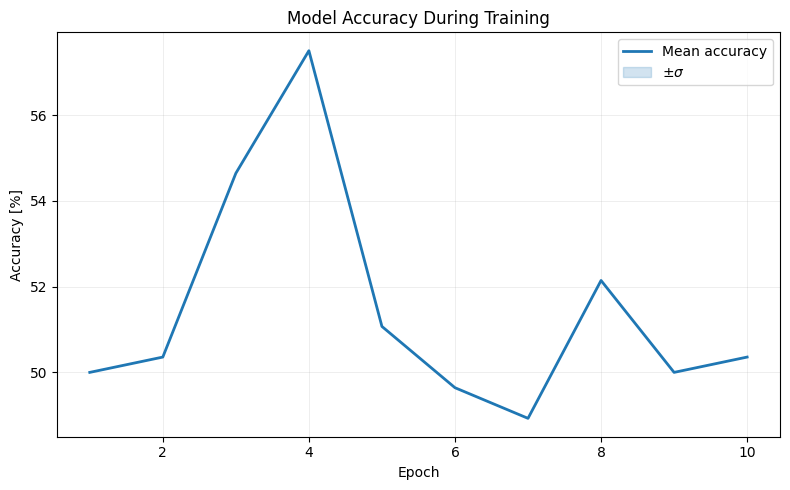

In [11]:
data_array = torch.tensor(
    [results[i]['accuracy'] for i in range(len(results))],
    dtype=torch.float32
)

plotter = DataVisualizer()
means, stds = plotter.calculate_statistics(data_array)
plotter.plot_statistics(means, stds)